In [4]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xgboost as xgb

In [5]:
example = r'10_EBO' ## needs user interaction
path_user = r'C:\Users\haris\Documents\GitHub\MLpFEM\data\\'

examples = [example]
folders = ['02_rawdata_interpolated\\']
folders = ['0_rawdata_interpolated\\', 
           '1_Pred1\\',
           '2_Pred2\\',
           '3_Pred3\\',
           '4_Pred4\\',
           '5_Pred5\\',
           '6_Pred6\\']
labels = ['TV', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6']
markersizes = [5, 0, 0,0,0,0,0, 0]
markeverys= [10,15,25, 25, 25, 25, 25]
colors = ['gray',  'cyan', 'green', 'magenta', 'purple', 'orange', 'black', 'brown', 'pink', 'cyan', 'yellow']
cm = 1/2.54  # centimeters in inches
markers = ['o', 'o', 'o', 's', 'd', 's', '+']

file_names = ["Triaxial test_q_eps1.txt", "Triaxial test_epsvol.txt", "Triaxial test_path.txt", "Oedometer.txt"]

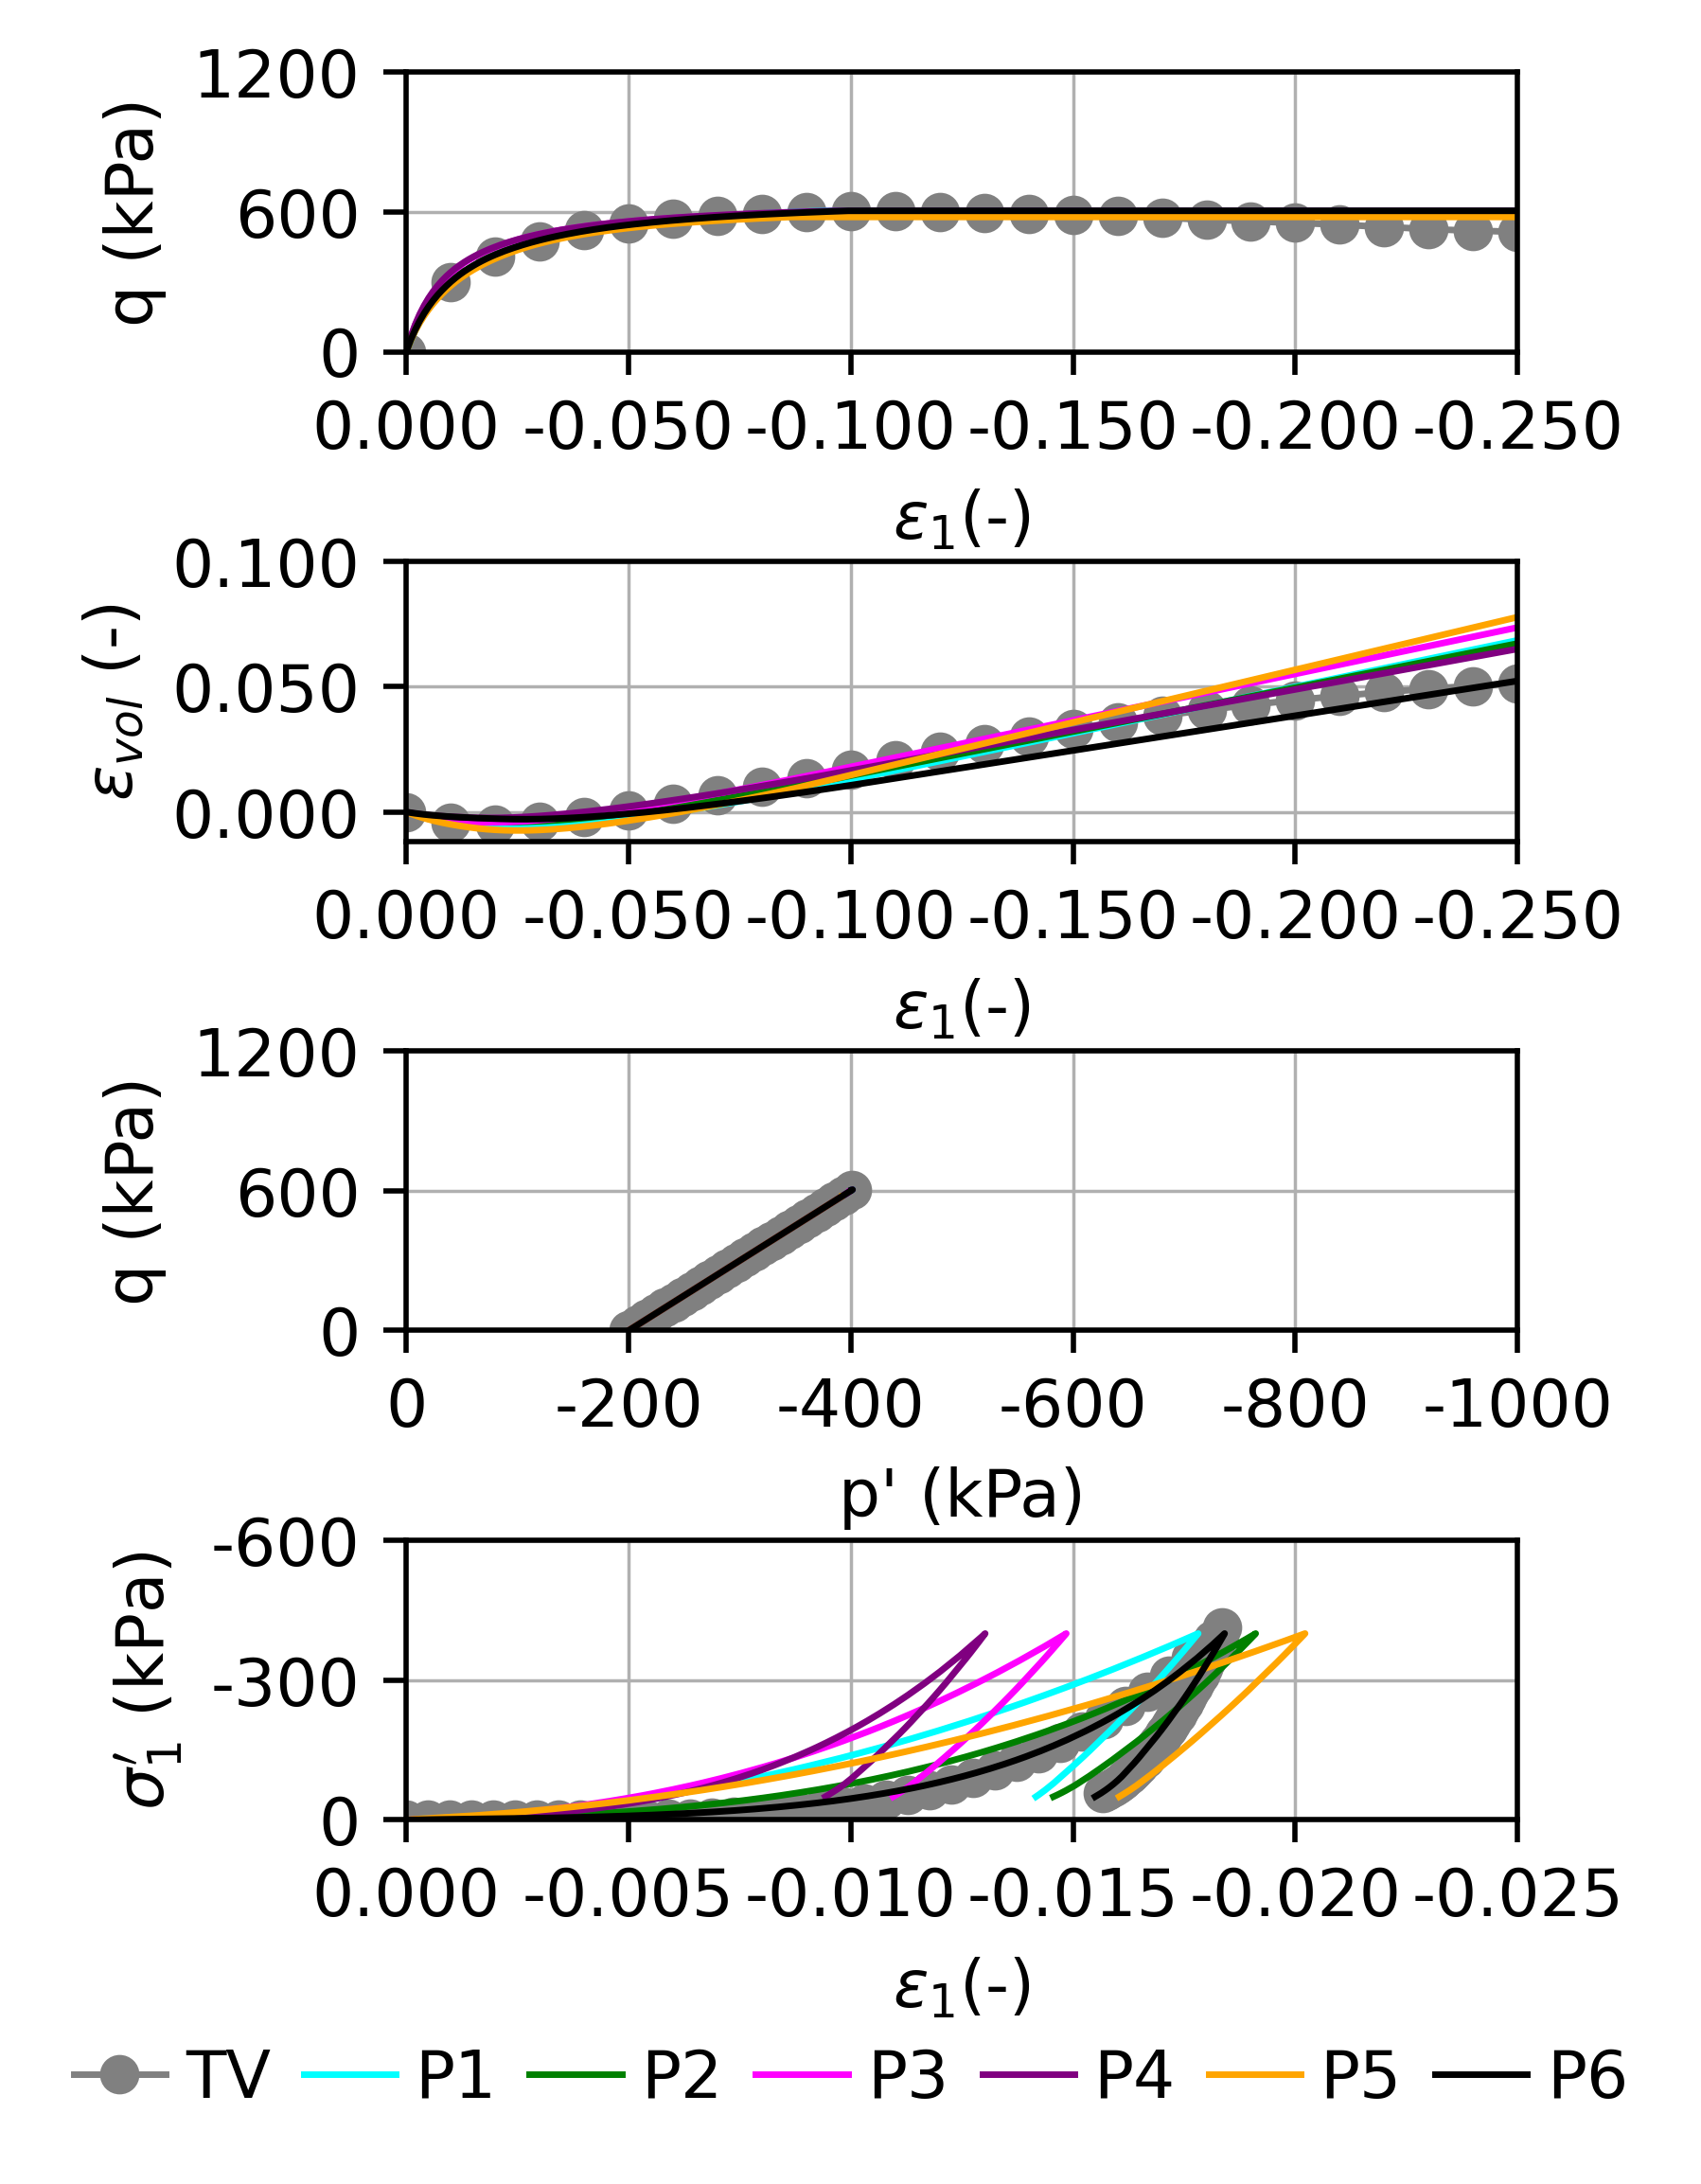

In [6]:
for k, example in enumerate(examples):
    fig, axs = plt.subplots(4, 1, figsize=(8.4 * cm, 11.1 * cm), dpi=500)  # Changed to 4 rows, 1 column

    for i, folder in enumerate(folders):
        for j, file_name in enumerate(file_names):
            df_data_syn = pd.read_csv(path_user + example + "\\" + folder + file_name, sep="\t", header=None)
            x = df_data_syn.iloc[:, 0]
            y = df_data_syn.iloc[:, 1]

            x = np.array(x)
            y = np.array(y)

            axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i])
            axs[j].grid(True, linewidth=0.5)
            axs[j].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

            axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[3].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))

            # Invert x-axis for all plots
            axs[j].invert_xaxis()

            axs[j].set_xlabel('$\epsilon_{1}$(-)')
            
            axs[2].set_xlabel("p' (kPa)")
            axs[0].set_ylabel('q (kPa)')
            axs[2].set_ylabel('q (kPa)')

            axs[1].set_ylabel('$\epsilon_{vol}$ (-)')
            axs[3].set_ylabel("$\sigma_{1}'$ (kPa)")

            if j == 2:  # stress path
                default_ticks = axs[1].get_xticks()
                axs[2].set_yticks([0, 600, 1200])
                axs[2].set_ylim(0)
                axs[2].set_xlim(xmin=0, xmax=-1000)
            if j == 0:  # stress strain
                axs[0].set_xlim(0, -0.25)
                axs[0].set_yticks([0, 600, 1200])
                axs[0].set_ylim(0)
            if j == 1:  # volumetric behaviour
                axs[1].set_yticks([0, 0.05,0.10])
                axs[1].set_xlim(0, -0.25)

            if j == 3:  # oedoemeter
                axs[3].set_ylim(-600, 0)
                axs[3].set_yticks([0, -300, -600])
                axs[3].set_xlim(-0.025, 0)
                axs[3].invert_yaxis()
                axs[3].invert_xaxis()

    # Create legend outside the loop
    plt.legend(loc='upper center', bbox_to_anchor=(0.40, -.60), frameon=False, ncol=7, handletextpad=0.3, columnspacing=0.5, handlelength=1.4)
    plt.subplots_adjust(left=0.22, right=0.93, bottom=0.14, top=0.985, wspace=0.40, hspace=0.75)
    plt.savefig(r"../graphics/" + "RealData" + f"{example}" + ".png", dpi=1000)